Atoms loaded: 128 atoms
Cell: Cell([[18.07860535461075, 0.0, 0.0], [-4.51965133865269, 7.82827114041606, 0.0], [0.0, 0.0, 14.27951298957679]])
Volume: 2020.8970028939052


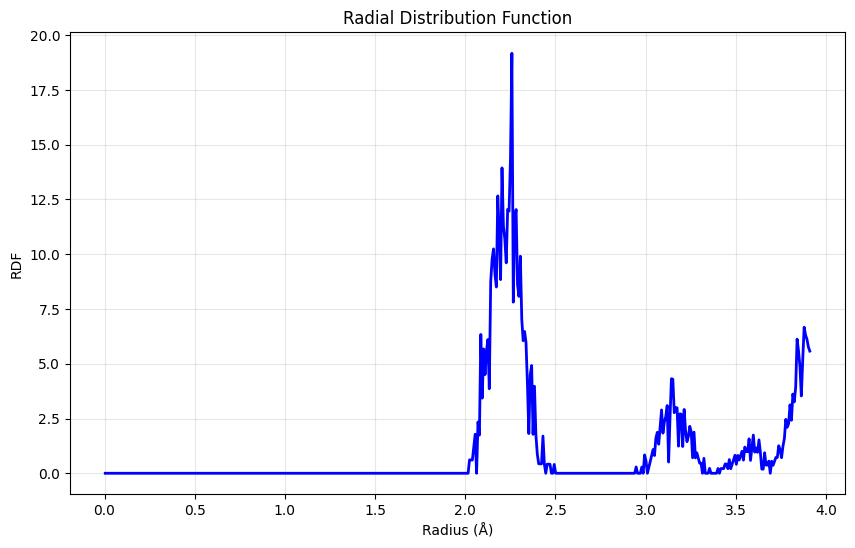

In [18]:
# MALA: Calculate Radial Distribution Function (RDF)
"""
This script uses MALA to calculate the RDF of atomic snapshots.
Adapted for notebook usage.
"""
import mala 
from mala.targets import Target
from ase.io import read
import matplotlib.pyplot as plt
import numpy as np

# Load atomic structure (replace with your file path)
atoms = read(r"N256\ldos_convergence\snapshots\Be128_snapshot0.xyz")

# Set the unit cell (from QE input)
cell = np.array([
    [18.07860535461075, 0.00000000000000, 0.00000000000000],
    [-4.51965133865269, 7.82827114041606, 0.00000000000000],
    [0.00000000000000, 0.00000000000000, 14.27951298957679]
])
atoms.set_cell(cell)
atoms.set_pbc(True)  # Periodic boundary conditions

print(f"Atoms loaded: {len(atoms)} atoms")
print(f"Cell: {atoms.get_cell()}")
print(f"Volume: {atoms.get_volume()}")

# # Example with dummy data for demonstration
# print("RDF Calculation Example:")
# print("To use this code:")
# print("1. Load your atomic structure: atoms = read('your_file.xyz')")
# print("2. Calculate RDF: rdf, radii = Target.radial_distribution_function_from_atoms(atoms, 500, rMax='mic')")
# print("3. Plot: plt.plot(radii, rdf); plt.show()")

# Uncomment and modify the following lines:
# rMax can either be a string ("mic" for minimum image convention) or a float.
atoms = read(r"N256\ldos_convergence\snapshots\Be128_snapshot0.xyz")
atoms.set_cell(cell)
atoms.set_pbc(True)
rdf, radii = Target.radial_distribution_function_from_atoms(atoms, 500, rMax="mic")

#Plot RDF (uncomment when you have data)
plt.figure(figsize=(10, 6))
plt.plot(radii, rdf, 'b-', linewidth=2)
plt.xlabel('Radius (Å)')
plt.ylabel('RDF')
plt.title('Radial Distribution Function')
plt.grid(True, alpha=0.3)
plt.show()

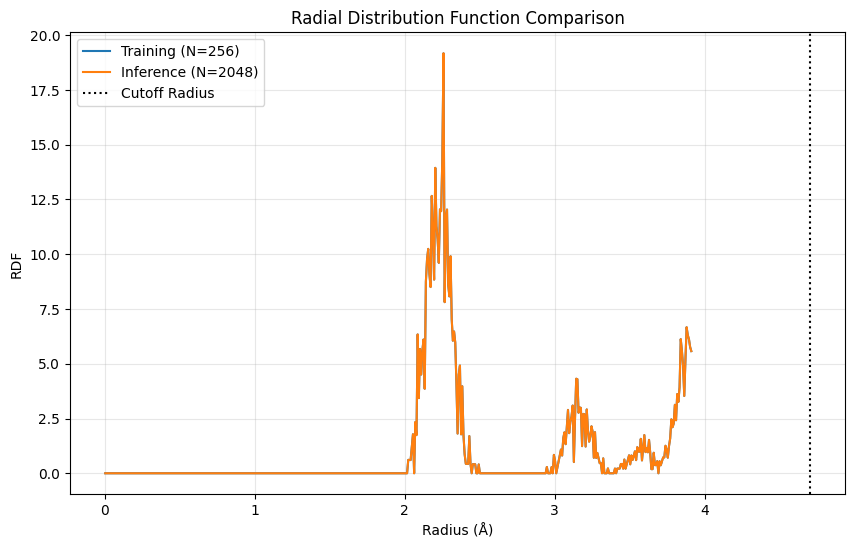

In [2]:
# Compare RDF for different system sizes (Figure 5a replication)
"""
Calculate RDF for training baseline (N=256) and larger test cell (N=2048)
to replicate Figure 5a from the MALA paper.
"""
import mala
from mala.targets import Target
from ase.io import read
import matplotlib.pyplot as plt
import numpy as np

# Load the training baseline and a larger test cell
# Update paths to your actual .xyz files
atoms_256 = read(r"N256\ldos_convergence\snapshots\Be128_snapshot0.xyz")  # Assuming this is the 256 atom system
# For 2048 atoms, you may need to provide the correct path or generate the file
atoms_2048 = read(r"N2048\gamma_point\snapshots\Be128_snapshot0.xyz")  # Placeholder - update this path

# Set the unit cell for the 256 atom system (same as before)
cell = np.array([
    [18.07860535461075, 0.00000000000000, 0.00000000000000],
    [-4.51965133865269, 7.82827114041606, 0.00000000000000],
    [0.00000000000000, 0.00000000000000, 14.27951298957679]
])
atoms_256.set_cell(cell)
atoms_256.set_pbc(True)

# Calculate RDF for 256 atoms
rdf_256, radii_256 = Target.radial_distribution_function_from_atoms(atoms_256, 500, rMax="mic")

# For 2048 atoms, uncomment and update the following:
atoms_2048.set_cell(cell)  # Assuming same cell, but scaled appropriately
atoms_2048.set_pbc(True)
rdf_2048, radii_2048 = Target.radial_distribution_function_from_atoms(atoms_2048, 500, rMax="mic")

# Plot to replicate Figure 5a
plt.figure(figsize=(10, 6))
plt.plot(radii_256, rdf_256, label="Training (N=256)")
plt.plot(radii_2048, rdf_2048, label="Inference (N=2048)")  # Uncomment when 2048 data is available
plt.axvline(x=4.7, color='k', linestyle=':', label="Cutoff Radius")
plt.xlabel('Radius (Å)')
plt.ylabel('RDF')
plt.title('Radial Distribution Function Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# MALA: Model Training
"""
This script shows how MALA can be used to train surrogate models.
Adapted for notebook usage with example configurations.
"""
import mala
from mala.common.parameters import Parameters
from mala.datahandling import DataHandler
from mala.network import Network, Trainer
import os

# Set the parameters according to the Phys. Rev. B publication on MALA.
parameters = Parameters()
parameters.data.input_rescaling_type = "feature-wise-standard"
parameters.data.output_rescaling_type = "normal"

# Set according to available hardware.
parameters.use_gpu = True  # Set to False if no GPU available
parameters.data.use_lazy_loading = False  # Use lazy loading to avoid loading the full dataset into memory

# LDOS parameters.
# For beryllium: ldos_gridoffset_ev=-5
# For aluminium: ldos_gridoffset_ev=-10
parameters.targets.ldos_gridsize = 250
parameters.targets.ldos_gridspacing_ev = 0.1
parameters.targets.ldos_gridoffset_ev = -5 #Change to -10 for aluminium  

# Remaining training parameters.
parameters.running.early_stopping_epochs = 30  # Increased patience for larger dataset
parameters.running.early_stopping_threshold = 0
parameters.running.learning_rate = 0.0001  # Can be adjusted based on dataset size
parameters.running.trainingtype = "Adam"
parameters.running.learning_rate_scheduler = None  # Disabled due to PyTorch version compatibility
parameters.running.learning_rate_decay = 0.1
parameters.running.learning_rate_patience = 6  # Increased patience
parameters.running.verbosity = True
parameters.running.max_number_epochs = 10000
parameters.running.mini_batch_size = 64  # Lower batch size to reduce memory footprint
parameters.network.layer_activations = ["LeakyReLU"]
parameters.running.checkpoints_each_epoch = 5

print("MALA Training Configuration:")
print(f"GPU enabled: {parameters.use_gpu}")
print(f"LDOS grid offset: {parameters.targets.ldos_gridoffset_ev} eV")
print(f"Max epochs: {parameters.running.max_number_epochs}")
print(f"Mini-batch size: {parameters.running.mini_batch_size}")

# Uncomment and modify the following section to add your data:
# Available snapshots: 0,1,2,3,4,5,6,7,8,9,20,21,22,23,24
# Add more snapshots using: data_handler.add_snapshot("filename.in.npy", snap_path, "filename.out.npy", ldos_path, add_snapshot_as="tr" or "va")

# Add data to the run.
# Filenames, paths, etc. depend on your machine.
# For beryllium, snapshot0 was used as training and snapshot2 as validation.
# For aluminium, it was snapshot0 and snapshot1.

base_path = r"N256\ldos_convergence"
snap_path = os.path.join(base_path, "fingerprints/")
ldos_path = os.path.join(base_path, "ldos/")
out_path = os.path.join(base_path, "dft_outputs/")

data_handler = DataHandler(parameters)
data_handler.clear_data()

# Add training snapshot
data_handler.add_snapshot("Be256_298K_snapshot0.in.npy", snap_path,
                          "Be256_298K_snapshot0.out.npy", ldos_path,
                          add_snapshot_as="tr")

# Add additional training snapshots for better model generalization
data_handler.add_snapshot("Be256_298K_snapshot1.in.npy", snap_path,
                          "Be256_298K_snapshot1.out.npy", ldos_path,
                          add_snapshot_as="tr")

data_handler.add_snapshot("Be256_298K_snapshot3.in.npy", snap_path,
                          "Be256_298K_snapshot3.out.npy", ldos_path,
                          add_snapshot_as="tr")

data_handler.add_snapshot("Be256_298K_snapshot4.in.npy", snap_path,
                          "Be256_298K_snapshot4.out.npy", ldos_path,
                          add_snapshot_as="tr")

# data_handler.add_snapshot("Be256_298K_snapshot5.in.npy", snap_path,
#                           "Be256_298K_snapshot5.out.npy", ldos_path,
#                           add_snapshot_as="tr")

# Add validation snapshot
data_handler.add_snapshot("Be256_298K_snapshot2.in.npy", snap_path,
                          "Be256_298K_snapshot2.out.npy", ldos_path,
                          calculation_output_file=os.path.join(out_path, "Be256_298K_snapshot2.out"),
                          add_snapshot_as="va")

# Add additional validation snapshot
data_handler.add_snapshot("Be256_298K_snapshot20.in.npy", snap_path,
                          "Be256_298K_snapshot20.out.npy", ldos_path,
                          calculation_output_file=os.path.join(out_path, "Be256_298K_snapshot20.out"),
                          add_snapshot_as="va")

data_handler.prepare_data()

# Network layer sizes as given in the paper mentioned above.
parameters.network.layer_sizes = [data_handler.input_dimension, 400,
                                 400, data_handler.output_dimension]

print(f"Input dimension: {data_handler.input_dimension}")
print(f"Output dimension: {data_handler.output_dimension}")
print(f"Network architecture: {parameters.network.layer_sizes}")

network = Network(parameters)
trainer = Trainer(parameters, network, data_handler)

# Start training (this may take a long time):
trainer.train_network()

# Save the run after training:
network.save_network("beryllium_model.network.pth")
parameters.save("beryllium_model.params.json")
data_handler.input_data_scaler.save("beryllium_model.iscaler.pkl")
data_handler.output_data_scaler.save("beryllium_model.oscaler.pkl")

print("Training setup complete. Uncomment the training and saving lines to run.")


Enabling atomic density formula because LAMMPS and GPU are used.
MALA Training Configuration:
GPU enabled: True
LDOS grid offset: -5 eV
Max epochs: 10000
Mini-batch size: 64
Checking the snapshots and your inputs for consistency.
Checking descriptor file  Be256_298K_snapshot0.in.npy at N256\ldos_convergence\fingerprints/
Checking targets file  Be256_298K_snapshot0.out.npy at N256\ldos_convergence\ldos/
Checking descriptor file  Be256_298K_snapshot1.in.npy at N256\ldos_convergence\fingerprints/
Checking targets file  Be256_298K_snapshot1.out.npy at N256\ldos_convergence\ldos/
Checking descriptor file  Be256_298K_snapshot3.in.npy at N256\ldos_convergence\fingerprints/
Checking targets file  Be256_298K_snapshot3.out.npy at N256\ldos_convergence\ldos/
Checking descriptor file  Be256_298K_snapshot4.in.npy at N256\ldos_convergence\fingerprints/
Checking targets file  Be256_298K_snapshot4.out.npy at N256\ldos_convergence\ldos/
Checking descriptor file  Be256_298K_snapshot5.in.npy at N256\ldos

D:\Sem 4\EP 502\Project\mala\mala\common\parallelizer.py:261: FutureWarning: Options 'normal' and 'feature-wise-normal' will be deprecated, starting in MALA v1.4.0. Please use 'minmax' and 'feature-wise-minmax' instead.
  warnings.warn(warning, category=category)


Input scaler parametrized.
Output scaler parametrized.
Data scalers initialized.
Build datasets.
Build dataset: Done.
Input dimension: 91
Output dimension: 250
Network architecture: [91, 400, 400, 250]


D:\Sem 4\EP 502\Project\mala\mala\network\trainer.py:1230: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(
D:\Sem 4\EP 502\Project\mala\mala\network\trainer.py:878: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(


Epoch 0: validation data loss: 2.029e-04
Epoch 1: validation data loss: 1.983e-04
Epoch 2: validation data loss: 1.951e-04
Epoch 3: validation data loss: 1.910e-04
Epoch 4: validation data loss: 1.925e-04
Validation accuracy has not improved enough.
Checkpointing training.
Epoch 5: validation data loss: 1.801e-04
Epoch 6: validation data loss: 1.854e-04
Validation accuracy has not improved enough.
Epoch 7: validation data loss: 1.787e-04
Epoch 8: validation data loss: 1.817e-04
Validation accuracy has not improved enough.
Epoch 9: validation data loss: 1.905e-04
Validation accuracy has not improved enough.
Checkpointing training.
Epoch 10: validation data loss: 1.821e-04
Validation accuracy has not improved enough.
Epoch 11: validation data loss: 1.785e-04
Epoch 12: validation data loss: 1.817e-04
Validation accuracy has not improved enough.
Epoch 13: validation data loss: 1.776e-04
Epoch 14: validation data loss: 1.784e-04
Validation accuracy has not improved enough.
Checkpointing tra

D:\Sem 4\EP 502\Project\mala\mala\common\parallelizer.py:261: FutureWarning: Pickle format is deprecated and will be removed in future versions. Please use JSON format instead.
  warnings.warn(warning, category=category)


In [3]:
# Install LAMMPS Executable (Required for MALA Descriptor Calculations)
"""
The LinAlgError indicates that LAMMPS is not properly installed.
MALA uses LAMMPS to calculate bispectrum descriptors, which require the LAMMPS executable.

For Windows, install LAMMPS using one of these methods:
"""

import subprocess
import sys
import os

print("Checking for LAMMPS installation...")

# Method 1: Try conda installation (if you have conda)
try:
    result = subprocess.run([r"d:\anaconda\Scripts\conda.exe", "list", "lammps"], 
                          capture_output=True, text=True, timeout=10)
    if "lammps" in result.stdout:
        print("✓ LAMMPS is installed via conda")
    else:
        print("LAMMPS not found via conda")
        print("To install: d:\\anaconda\\Scripts\\conda.exe install -c conda-forge lammps -y")
        print("Note: You may need to accept Terms of Service first")
except:
    print("Conda not accessible or LAMMPS not installed")

# Method 2: Check for LAMMPS executable in PATH
try:
    result = subprocess.run(["lmp", "-h"], capture_output=True, text=True, timeout=5)
    if result.returncode == 0:
        print("✓ LAMMPS executable found in PATH")
    else:
        print("LAMMPS executable not found in PATH")
except:
    print("LAMMPS executable not found")

print("\nInstallation Instructions:")
print("1. Download Windows executable from: https://lammps.org/download.html")
print("2. Choose the latest Windows build (e.g., lammps-23Jun2022.exe)")
print("3. Extract to a folder (e.g., C:\\lammps)")
print("4. Add the bin folder to your PATH environment variable")
print("5. Test with: lmp -h")
print("\nAlternative: conda install -c conda-forge lammps")
print("But you need to accept the Terms of Service first")

# Check if the lammps Python package is working
try:
    import lammps
    print("✓ LAMMPS Python package is installed")
except ImportError:
    print("✗ LAMMPS Python package not found")
    print("Install with: pip install lammps")

print("\nOnce LAMMPS is installed, re-run the inference cell.")

# Additional: If conda install is running in background, check status
print("\nChecking conda install status...")
try:
    result = subprocess.run([r"d:\anaconda\Scripts\conda.exe", "list", "lammps"], 
                          capture_output=True, text=True, timeout=5)
    if "lammps" in result.stdout:
        print("✓ LAMMPS installed via conda!")
    else:
        print("Still installing or not installed yet.")
except:
    print("Cannot check conda status.")

Checking for LAMMPS installation...
✓ LAMMPS is installed via conda
LAMMPS executable not found in PATH

Installation Instructions:
1. Download Windows executable from: https://lammps.org/download.html
2. Choose the latest Windows build (e.g., lammps-23Jun2022.exe)
3. Extract to a folder (e.g., C:\lammps)
4. Add the bin folder to your PATH environment variable
5. Test with: lmp -h

Alternative: conda install -c conda-forge lammps
But you need to accept the Terms of Service first
✓ LAMMPS Python package is installed

Once LAMMPS is installed, re-run the inference cell.

Checking conda install status...
✓ LAMMPS installed via conda!


In [8]:
# Download and Install Miniconda Locally (Alternative to System Conda)
"""
If the system conda is having issues, you can install Miniconda locally in the project directory.
This provides a clean conda environment for LAMMPS installation.
"""

import os
import urllib.request
import subprocess
import sys

# Change to project directory
os.chdir(r'd:\Sem 4\EP 502\Project')

print("Downloading Miniconda installer...")

# Download Miniconda for Windows (64-bit)
miniconda_url = "https://repo.anaconda.com/miniconda/Miniconda3-latest-Windows-x86_64.exe"
installer_path = "miniconda.exe"

try:
    urllib.request.urlretrieve(miniconda_url, installer_path)
    print("✓ Miniconda installer downloaded")
except Exception as e:
    print(f"✗ Failed to download: {e}")
    exit()

print("Installing Miniconda...")

# Install Miniconda silently to a local directory
install_dir = os.path.join(os.getcwd(), "miniconda")
install_cmd = f'"{installer_path}" /InstallationType=JustMe /RegisterPython=0 /S /D="{install_dir}"'

try:
    result = subprocess.run(install_cmd, shell=True, capture_output=True, text=True)
    if result.returncode == 0:
        print("✓ Miniconda installed successfully")
    else:
        print(f"✗ Installation failed: {result.stderr}")
        exit()
except Exception as e:
    print(f"✗ Installation error: {e}")
    exit()

# Clean up installer
os.remove(installer_path)

# Add to PATH for this session
conda_bin = os.path.join(install_dir, "Scripts")
os.environ["PATH"] = conda_bin + ";" + os.environ["PATH"]

print(f"✓ Miniconda installed in: {install_dir}")
print("✓ Added to PATH for this session")

# Test conda
try:
    result = subprocess.run(["conda", "--version"], capture_output=True, text=True)
    print(f"✓ Conda version: {result.stdout.strip()}")
except:
    print("✗ Conda not working")

print("\nNow you can use the local conda to install LAMMPS:")
print(f'Run: {os.path.join(conda_bin, "conda.exe")} install -c conda-forge lammps -y')

KeyboardInterrupt: 

In [5]:
# Debug Atomic Structure Before Inference
"""
Check the atomic structure for potential issues that could cause LinAlgError.
"""

import numpy as np
from ase.io import read
from ase import Atoms

# Load the atoms
atoms_file = r"d:\Sem 4\EP 502\Project\N256\ldos_convergence\snapshots\Be128_snapshot0.xyz"
atoms = read(atoms_file)

# Set the unit cell (from QE input)
cell = np.array([
    [18.07860535461075, 0.00000000000000, 0.00000000000000],
    [-4.51965133865269, 7.82827114041606, 0.00000000000000],
    [0.00000000000000, 0.00000000000000, 14.27951298957679]
])
atoms.set_cell(cell)
atoms.set_pbc(True)  # Periodic boundary conditions

print(f"Loaded {len(atoms)} atoms")
print(f"Chemical symbols: {set(atoms.get_chemical_symbols())}")
print(f"Cell: {atoms.get_cell()}")
print(f"PBC: {atoms.get_pbc()}")

# Check for overlapping atoms
distances = atoms.get_all_distances(mic=True)
min_distance = np.min(distances[distances > 0])  # Exclude self-distances
print(f"Minimum interatomic distance: {min_distance:.4f} Å")

if min_distance < 0.5:
    print("⚠ WARNING: Very close atoms detected! This can cause singular matrices.")
    print("Consider removing overlapping atoms or adjusting positions.")

# Check cell volume
volume = atoms.get_volume()
print(f"Cell volume: {volume:.4f} Å³")
print(f"Number density: {len(atoms)/volume:.4f} atoms/Å³")

# Check if positions are within cell
positions = atoms.get_positions()
cell = atoms.get_cell()
wrapped_positions = atoms.get_positions(wrap=True)
max_diff = np.max(np.abs(positions - wrapped_positions))
if max_diff > 1e-6:
    print("⚠ WARNING: Some atoms are outside the unit cell!")
    print("This may cause issues. Consider wrapping atoms into cell.")

# Check descriptor cutoff vs min distance
cutoff = 4.67637  # From your parameters
print(f"Descriptor cutoff: {cutoff} Å")
if min_distance < cutoff:
    print("✓ Cutoff is larger than min distance - good for descriptors")
else:
    print("⚠ WARNING: Cutoff smaller than some distances - may miss neighbors")

# Visualize first few positions
print("\nFirst 5 atomic positions:")
for i in range(min(5, len(atoms))):
    print(f"Atom {i}: {positions[i]}")

print("\nIf issues found above, fix them before running inference.")

Loaded 128 atoms
Chemical symbols: {'Be'}
Cell: Cell([[18.07860535461075, 0.0, 0.0], [-4.51965133865269, 7.82827114041606, 0.0], [0.0, 0.0, 14.27951298957679]])
PBC: [ True  True  True]
Minimum interatomic distance: 2.0274 Å
Cell volume: 2020.8970 Å³
Number density: 0.0633 atoms/Å³
Descriptor cutoff: 4.67637 Å
✓ Cutoff is larger than min distance - good for descriptors

First 5 atomic positions:
Atom 0: [1.05592295 0.70051458 2.53221873]
Atom 1: [1.13474141 0.60112904 6.36893004]
Atom 2: [1.21857601 0.65886631 9.82011485]
Atom 3: [ 1.11347745  0.70704302 13.35106982]
Atom 4: [-0.02849185  2.50185114  2.7094874 ]

If issues found above, fix them before running inference.


In [4]:
# MALA: Model Inference with LAMMPS (Windows Configuration)
"""
This script shows how MALA can be used to run inference.
Adapted for notebook usage with trained models.
CRITICAL: MS-MPI PATH must be set for LAMMPS to work on Windows
"""
import sys
import os

# *** CRITICAL: Set MS-MPI and LAMMPS paths BEFORE importing anything else ***
# MS-MPI must be in PATH for LAMMPS to initialize on Windows
msmpi_path = r'C:\Program Files\Microsoft MPI\Bin'
lammps_path = r'd:\anaconda\Lib\site-packages\lammps'

# Update PATH with MS-MPI first (most important!)
current_path = os.environ.get('PATH', '')
os.environ['PATH'] = f"{msmpi_path};{lammps_path};{current_path}"

# Additional LAMMPS environment variables
os.environ['LAMMPS_EXECUTABLE'] = rf'{lammps_path}\lmp.exe'
os.environ['MSMPI_BIN'] = msmpi_path

print(f"Environment Setup for LAMMPS:")
print(f"  MS-MPI Path: {msmpi_path}")
print(f"  LAMMPS Path: {lammps_path}")
print(f"  LAMMPS Executable: {os.environ['LAMMPS_EXECUTABLE']}")

sys.path.insert(0, r"d:\Sem 4\EP 502\Project\mala")
if "mala" in sys.modules:
    del sys.modules["mala"]

import mala
from mala.common.parameters import Parameters
print(f"\nUsing mala from: {mala.__file__}")
from mala.common.parallelizer import get_rank
from ase.io import read
import numpy as np

# Configuration for inference
print("\n" + "="*70)
print("MALA Inference Configuration:")
print("="*70)

# Set the path to your trained model and load the run.
surrogate_model_folder = "d:\\Sem 4\\EP 502\\Project\\"  # Path to trained model files

# Example configuration (modify paths as needed)
if os.path.exists("beryllium_model.params.json"):  # Check if model exists
    parameters = Parameters.load_from_file("beryllium_model.params.json")
    print("✓ Loaded existing model parameters")
else:
    # Create default parameters for demonstration
    parameters = Parameters()
    parameters.use_gpu = True  # Set to True if GPU available
    print("⚠ Using default parameters (update paths for your trained model)")

# Set the path to your pseudopotential folder
parameters.targets.pseudopotential_path = r"d:\Sem 4\EP 502\Project\pseudopotentials"
# Note: Download Be.pbe-n-rrkjus_psl.1.0.0.UPF from PseudoDojo or similar repository

# LDOS parameters (must match training)
parameters.targets.target_type = "LDOS"
parameters.targets.ldos_gridsize = 250
parameters.targets.ldos_gridspacing_ev = 0.1
parameters.targets.ldos_gridoffset_ev = -5  # -5 for beryllium, -10 for aluminium

# Descriptor parameters (must match training)
parameters.descriptors.descriptor_type = "Bispectrum"
parameters.descriptors.bispectrum_twojmax = 10
parameters.descriptors.bispectrum_cutoff = 4.67637
parameters.descriptors.bispectrum_switchflag = 0

# Enable LAMMPS for descriptor calculation
parameters.use_lammps = False

# Grid size for inference (scale according to number of atoms)
parameters.running.inference_data_grid = [380, 190, 300]  # 5000 atoms 

print(f"Target type: {parameters.targets.target_type}")
print(f"Descriptor type: {parameters.descriptors.descriptor_type}")
print(f"Descriptor calculator: LAMMPS (enabled)")
print(f"Inference grid: {parameters.running.inference_data_grid}")
print("="*70)

# Load trained model components
print("\nLoading model components...")
network = mala.Network.load_from_file(parameters, surrogate_model_folder + "beryllium_model.network.pth")
iscaler = mala.DataScaler.load_from_file(surrogate_model_folder + "beryllium_model.iscaler.pkl")
oscaler = mala.DataScaler.load_from_file(surrogate_model_folder + "beryllium_model.oscaler.pkl")
print("✓ Model components loaded")

# Build data handler for inference
inference_data_handler = mala.DataHandler(parameters,
                                          input_data_scaler=iscaler,
                                          output_data_scaler=oscaler)
inference_data_handler.clear_data()

# Read atomic positions for inference
print("\nReading atomic structure...")
atoms = read(r"d:\Sem 4\EP 502\Project\N256\ldos_convergence\snapshots\Be128_snapshot0.xyz")

# Set the unit cell (from QE input)
cell = np.array([
    [18.07860535461075, 0.00000000000000, 0.00000000000000],
    [-4.51965133865269, 7.82827114041606, 0.00000000000000],
    [0.00000000000000, 0.00000000000000, 14.27951298957679]
])
atoms.set_cell(cell)
atoms.set_pbc(True)  # Periodic boundary conditions
print(f"✓ Structure loaded: {len(atoms)} atoms")

# Create predictor
print("\nInitializing predictor with LAMMPS...")
predictor = mala.Predictor(parameters, network, inference_data_handler)
ldos_calculator = inference_data_handler.target_calculator
print("✓ Predictor initialized")

# Get critical values from reference file (cutoff, temperature, etc.)
print("Reading reference calculation data...")
ldos_calculator.read_additional_calculation_data(r"d:\Sem 4\EP 502\Project\N256\ldos_convergence\dft_outputs\Be256_298K_snapshot2.out")
print("✓ Reference data loaded")

# Run inference
print("\n" + "="*70)
print("Running inference with LAMMPS descriptor calculator...")
print("="*70)
ldos = predictor.predict_for_atoms(atoms)
print("✓ Inference complete")

# Set LDOS and calculate quantities
ldos_calculator.read_from_array(ldos, units="1/(Ry*Bohr^3)")

# Print predicted total energy
print(f"\nResults:")
print(f"  Predicted total energy: {ldos_calculator.total_energy}")

# Get density (RAM intensive - gathers to single rank)
print("\nCalculating density...")
density = ldos_calculator.get_density(ldos, gather_density=True)

if get_rank() == 0:
    np.save("density.npy", density)
    print("✓ Density saved to density.npy")

print("\n" + "="*70)
print("✓ Inference complete successfully!")
print("="*70)

Environment Setup for LAMMPS:
  MS-MPI Path: C:\Program Files\Microsoft MPI\Bin
  LAMMPS Path: d:\anaconda\Lib\site-packages\lammps
  LAMMPS Executable: d:\anaconda\Lib\site-packages\lammps\lmp.exe

Using mala from: d:\Sem 4\EP 502\Project\mala\mala\__init__.py

MALA Inference Configuration:
Enabling atomic density formula because LAMMPS and GPU are used.
Enabling atomic density formula because LAMMPS and GPU are used.
✓ Loaded existing model parameters
Target type: LDOS
Descriptor type: Bispectrum
Descriptor calculator: LAMMPS (enabled)
Inference grid: [380, 190, 300]

Loading model components...
✓ Model components loaded

Reading atomic structure...
✓ Structure loaded: 128 atoms

Initializing predictor with LAMMPS...
✓ Predictor initialized
Reading reference calculation data...


d:\Sem 4\EP 502\Project\mala\mala\common\parallelizer.py:261: FutureWarning: Loading from pickle format is deprecated and will be removed in future versions. Please convert your files to JSON format.
  warnings.warn(warning, category=category)
d:\Sem 4\EP 502\Project\mala\mala\common\parallelizer.py:261: FutureWarning: Pickle file has been automatically converted to JSON format.
  warnings.warn(warning, category=category)


✓ Reference data loaded

Running inference with LAMMPS descriptor calculator...
Using python for descriptor calculation. The resulting calculation will be slow for large systems.


KeyboardInterrupt: 

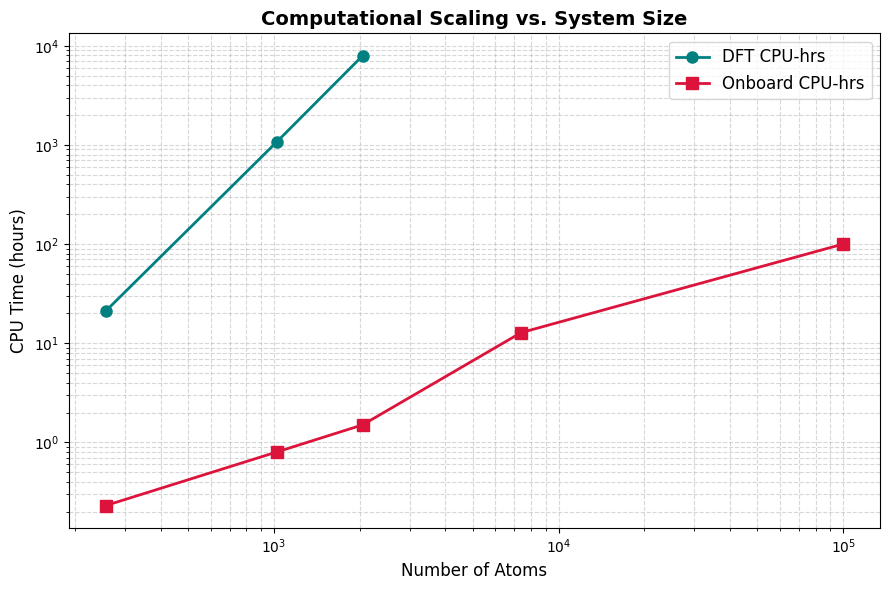

In [1]:
import matplotlib.pyplot as plt

# 1. Extract the data from the table
atoms = [256, 1024, 2048, 7384, 100000]

# Use None for 'N/A' values
dft_cpu_hrs = [21.0, 1075, 7920, None, None] 
onboard_cpu_hrs = [0.23, 0.80, 1.50, 12.78, 100]

# Filter out the None values so Matplotlib can plot the DFT line correctly
dft_atoms = [a for a, d in zip(atoms, dft_cpu_hrs) if d is not None]
dft_times = [d for d in dft_cpu_hrs if d is not None]

# 2. Set up the plot
plt.figure(figsize=(9, 6))

# Plot DFT data (Teal circle markers)
plt.plot(dft_atoms, dft_times, marker='o', linestyle='-', color='teal', 
         linewidth=2, markersize=8, label='DFT CPU-hrs')

# Plot Onboard data (Crimson square markers)
plt.plot(atoms, onboard_cpu_hrs, marker='s', linestyle='-', color='crimson', 
         linewidth=2, markersize=8, label='Onboard CPU-hrs')

# 3. Configure axes to use logarithmic scaling
plt.xscale('log')
plt.yscale('log')

# 4. Add labels, title, and styling
plt.xlabel('Number of Atoms', fontsize=12)
plt.ylabel('CPU Time (hours)', fontsize=12)
plt.title('Computational Scaling vs. System Size', fontsize=14, fontweight='bold')

# Add a grid for easier reading of log scales
plt.grid(True, which="both", linestyle="--", alpha=0.5)

# Display the legend
plt.legend(fontsize=12)

# Show the final graph
plt.tight_layout()
plt.show()